# Author Info
---
Name: **Ejaz-ur-Rehman**\
Business Unit Head | Data Analyst | Lecturer (Accounting & Finance)\
MBA (Accounting & Finance), MS (Finance)\
Crystal Tech (Project of MUZHAB Group) | Al Ghazali University\
Karachi, Pakistan

![Date](https://img.shields.io/badge/Date-03--June--2026-green?logo=google-calendar)
[![Email](https://img.shields.io/badge/Email-ijazfinance%40gmail.com-blue?logo=gmail)](mailto:ijazfinance@gmail.com)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Ejaz--ur--Rehman-blue?logo=linkedin)](https://www.linkedin.com/in/ejaz-ur-rehman/)
[![GitHub](https://img.shields.io/badge/GitHub-ejazurrehman-black?logo=github)](https://github.com/ejazurrehman)

# Project:
In this project, we're going to work with data from the Survey of Consumer Finances (SCF). The SCF is a survey sponsored by the US Federal Reserve. It tracks financial, demographic, and opinion information about families in the United States. The survey is conducted every three years, and we'll work with an extract of the results from 2022.

As you progress, you'll gain practical experience with key data science techniques, including:

- Preprocessing and analyzing survey-based financial datasets
- Applying k-means clustering to uncover meaningful household segments
- Reducing dimensionality using Principal Component Analysis (PCA)
- Creating and deploying an interactive Dash web application to visualize your findings
- By the end of the project, you'll have built a complete data pipeline—from clustering analysis to an interactive dashboard—that helps communicate insights about financially vulnerable households.

## About the Survey of Consumer Finances
From the US Federal Reserve website:

The Survey of Consumer Finances (SCF) is normally a triennial cross-sectional survey of U.S. families. The survey data include information on families’ balance sheets, pensions, income, and demographic characteristics. Information is also included from related surveys of pension providers and the earlier such surveys conducted by the Federal Reserve Board. No other study for the country collects comparable information. Data from the SCF are widely used, from analysis at the Federal Reserve and other branches of government to scholarly work at the major economic research centers.

# 1. Data Prepration

## 1.1 Importing Laibraries

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## 1.2 Read a CSV file into a DataFrame using pandas.
Including: Data Type, Shape and first five rows in the data.

### Task 1.1: Read the file "data/SCFP2022.csv" into the DataFrame df.

In [2]:
df = pd.read_csv(r"C:\Users\DELL\OneDrive\Data Science\Islamic_FinTech\scfp2022excel.zip")
print("df type:", type(df))
print("df shape:", df.shape)
df.head()

df type: <class 'pandas.core.frame.DataFrame'>
df shape: (22975, 357)


,YY1,Y1,WGT,HHSEX,AGE,AGECL,EDUC,EDCL,MARRIED,KIDS,...,NWCAT,INCCAT,ASSETCAT,NINCCAT,NINC2CAT,NWPCTLECAT,INCPCTLECAT,NINCPCTLECAT,INCQRTCAT,NINCQRTCAT
0,1,11,3027.956120,2,70,5,9,3,2,2,...,4,2,4,2,1,8,3,3,2,1
1,1,12,3054.900065,2,70,5,9,3,2,2,...,4,2,5,2,1,8,3,3,2,1
2,1,13,3163.637766,2,70,5,9,3,2,2,...,4,2,4,2,1,8,3,3,1,1
3,1,14,3166.228463,2,70,5,9,3,2,2,...,3,2,4,1,1,6,3,2,1,1
4,1,15,3235.624715,2,70,5,9,3,2,2,...,3,2,4,2,1,8,3,3,1,1


**NOTE**: One of the first things you might notice here is that this dataset is HUGE — over 22,000 rows and 357 columns! SO MUCH DATA!!! We won't have time to explore all of the features in this dataset, but you can look in the data dictionary for this project for details and links to the official Code Book. For now, let's just say that this dataset tracks all sorts of behaviors relating to the ways households earn, save, and spend money in the United States.

For this project, we're going to focus on households that have "been turned down for credit or feared being denied credit in the past 5 years." These households are identified in the "TURNFEAR" column.

### Task 1.2: Use a mask to subset create df to only households that have been turned down or feared being turned down for credit ("TURNFEAR" == 1). Assign this subset to the variable name df_fear.

In [ ]:
# Create a boolean mask where the "TURNFEAR" column is equal to 1
# This will return a Series of boolean values (True/False) indicating whether each row meets the condition.
mask = df["TURNFEAR"] == 1
mask.head(10)

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8    False
9    False
Name: TURNFEAR, dtype: bool

In [11]:
mask.sum()  # This will give us the count of rows where "TURNFEAR" is equal to 1

np.int64(3839)

In [ ]:
# Display the column names of df_fear to check for the presence of "AGECL"
mask = df["TURNFEAR"] == 1
df_fear = df[mask]
print("df_fear type:", type(df_fear))
print("df_fear shape:", df_fear.shape)
df_fear.head()

df_fear type: <class 'pandas.core.frame.DataFrame'>
df_fear shape: (3839, 357)


,YY1,Y1,WGT,HHSEX,AGE,AGECL,EDUC,EDCL,MARRIED,KIDS,...,NWCAT,INCCAT,ASSETCAT,NINCCAT,NINC2CAT,NWPCTLECAT,INCPCTLECAT,NINCPCTLECAT,INCQRTCAT,NINCQRTCAT
20,5,51,7191.481109,2,19,1,8,2,1,0,...,1,3,1,2,1,2,5,4,2,2
21,5,52,7352.487205,2,19,1,8,2,1,0,...,1,3,1,2,1,2,5,4,2,2
22,5,53,7270.703541,2,19,1,8,2,1,0,...,1,3,1,3,1,2,5,5,2,2
23,5,54,7383.866597,2,19,1,8,2,1,0,...,1,3,1,3,1,2,5,5,2,2
24,5,55,7330.537669,2,19,1,8,2,1,0,...,1,3,1,2,1,2,5,4,2,2


# 2. Data Exploration
- Now that we have our subset, let's explore the characteristics of this group. One of the features is age group ("AGECL").

### Task 2.1: Create a list age_groups with the unique values in the "AGECL" column. Then review the entry for "AGECL" in the Code Book (https://sda.berkeley.edu/sdaweb/docs/scfcomb2019/DOC/hcbk.htm) to determine what the values represent.

In [ ]:
# Display the column names of df_fear to check for the presence of "AGECL"
for col in df_fear.columns:
    print(repr(col))

'YY1'
'Y1'
'WGT'
'HHSEX'
'AGE'
'AGECL'
'EDUC'
'EDCL'
'MARRIED'
'KIDS'
'LF'
'LIFECL'
'FAMSTRUCT'
'RACECL'
'RACECL4'
'RACECL5'
'RACECL_EX'
'RACE'
'OCCAT1'
'OCCAT2'
'INDCAT'
'FOODHOME'
'FOODAWAY'
'FOODDELV'
'RENT'
'INCOME'
'WAGEINC'
'BUSSEFARMINC'
'INTDIVINC'
'KGINC'
'SSRETINC'
'TRANSFOTHINC'
'PENACCTWD'
'NORMINC'
'WSAVED'
'SAVED'
'SAVRES1'
'SAVRES2'
'SAVRES3'
'SAVRES4'
'SAVRES5'
'SAVRES6'
'SAVRES7'
'SAVRES8'
'SAVRES9'
'SPENDMOR'
'SPENDLESS'
'EXPENSHILO'
'LATE'
'LATE60'
'HPAYDAY'
'BNKRUPLAST5'
'KNOWL'
'YESFINRISK'
'NOFINRISK'
'CRDAPP'
'TURNDOWN'
'FEARDENIAL'
'TURNFEAR'
'FORECLLAST5'
'EMERGBORR'
'EMERGSAV'
'EMERGPSTP'
'EMERGCUT'
'EMERGWORK'
'HBORRFF'
'HBORRCC'
'HBORRALT'
'HBORRFIN'
'HSAVFIN'
'HSAVNFIN'
'HPSTPPAY'
'HPSTPLN'
'HPSTPOTH'
'HCUTFOOD'
'HCUTENT'
'HCUTOTH'
'FINLIT'
'BSHOPNONE'
'BSHOPGRDL'
'BSHOPMODR'
'ISHOPNONE'
'ISHOPGRDL'
'ISHOPMODR'
'BCALL'
'BMAGZNEWS'
'BMAILADTV'
'BINTERNET'
'BFRIENDWORK'
'BFINPRO'
'BSELF'
'BDONT'
'BOTHER'
'ICALL'
'IMAGZNEWS'
'IMAILADTV'
'IINTERNET'
'IFRIENDWOR

In [ ]:
# Assuming "AGECL" is a column in df_fear, we can display its first few values as follows:
df_fear["AGECL"].head()

20    1
21    1
22    1
23    1
24    1
Name: AGECL, dtype: int64

In [ ]:
# To find out how many unique values are in the "AGECL" column of df_fear, we can use the nunique() method:
df_fear["AGECL"].nunique()

6

In [12]:
age_groups = df_fear["AGECL"].nunique()
print("Age Groups:", age_groups)

Age Groups: 6


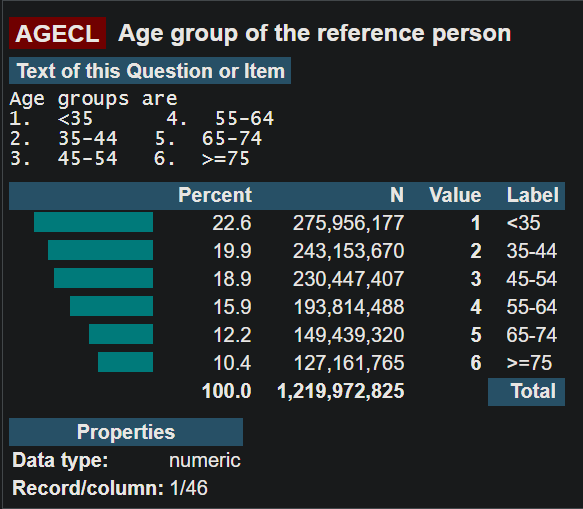

**NOTE:** Looking at the Code Book we can see that "AGECL" represents categorical data, even though the values in the column are numeric.
his simplifies data storage, but it's not very human-readable. So before we create a visualization, let's create a version of this column that uses the actual group names.

### Task 2.2: Create a Series agecl that contains the observations from "AGECL" using the true group names.

- Create a Series in pandas.
- Replace values in a column using pandas.

In [ ]:
# Display the first 10 values of the "AGECL" column in df_fear
df_fear["AGECL"].head(10)

20     1
21     1
22     1
23     1
24     1
110    4
111    4
112    4
113    4
114    4
Name: AGECL, dtype: int64

In [ ]:
# Create a dictionary to map the numeric values in "AGECL" to their corresponding age group labels.
agecl_dict = {
    1: "Under 35",
    2: "35-44",
    3: "45-54",
    4: "55-64",
    5: "65-74",
    6: "75 or Older",
}

# Use the replace() method to create a new Series with the numeric values in "AGECL" replaced by their corresponding age group labels.
age_cl = df_fear["AGECL"].replace(agecl_dict)
print("age_cl type:", type(age_cl))
print("age_cl shape:", age_cl.shape)
age_cl.head()

age_cl type: <class 'pandas.core.series.Series'>
age_cl shape: (3839,)


20    Under 35
21    Under 35
22    Under 35
23    Under 35
24    Under 35
Name: AGECL, dtype: object

### Task 2.3: Create a bar chart showing the value counts from age_cl. Be sure to label the x-axis "Age Group", the y-axis "Frequency (count)", and use the title "Credit Fearful: Age Groups".

- Create a bar chart using pandas.

In [ ]:
# Display the first few values of the age_cl Series to verify that the numeric values have been replaced with the corresponding age group labels.
age_cl.head()

20    Under 35
21    Under 35
22    Under 35
23    Under 35
24    Under 35
Name: AGECL, dtype: object

In [ ]:
# To find out how many times each age group appears in the age_cl Series, we can use the value_counts() method:
age_cl.value_counts()

AGECL
35-44          936
Under 35       917
45-54          802
55-64          682
65-74          398
75 or Older    104
Name: count, dtype: int64

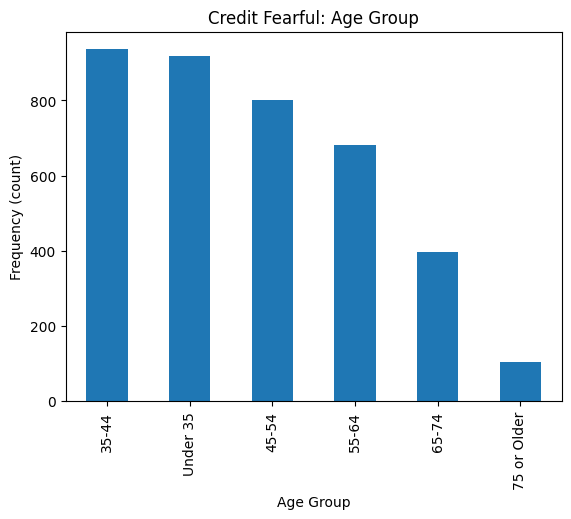

In [ ]:
# Store the result of age_cl.value_counts() in a variable for later use in plotting.
age_cl_value_counts = age_cl.value_counts()

# Bar plot of `age_cl_value_counts`
age_cl_value_counts.plot(
    kind = "bar",
    xlabel = "Age Group",
    ylabel = "Frequency (count)",
    title = "Credit Fearful: Age Group"
);

Interpretation: Credit Fearful: Age Group
- The chart shows that credit fear is most common among younger and middle-aged individuals. Respondents under 35 and those aged 35–44 have the highest frequencies of credit fear, with counts exceeding 900. The frequency gradually declines with age, falling to around 400 for the 65–74 group and just over 100 for those 75 or older. This suggests that younger adults are more likely to avoid applying for credit due to fear of rejection, while older individuals exhibit lower levels of credit fear.

### Task 2.4: Create a histogram of the "AGE" column with 10 bins. Be sure to label the x-axis "Age", the y-axis "Frequency (count)", and use the title "Credit Fearful: Age Distribution".

- Create a histogram using pandas.

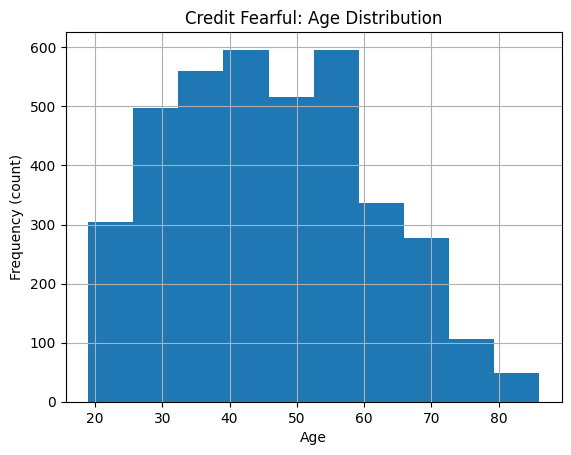

In [18]:
# Plot histogram of "AGE"
df_fear["AGE"].hist(bins=10)
plt.xlabel("Age")
plt.ylabel("Frequency (count)")
plt.title("Credit Fearful: Age Distribution");

Interpretation: Credit Fearful Age Distribution

The histogram illustrates the age distribution of respondents who reported being credit fearful, meaning they avoided applying for credit due to concerns about being denied.

Key observations include:

- The distribution is concentrated between 30 and 60 years of age, indicating that credit fear is most prevalent among working-age adults.
- The highest frequencies occur in the 40–60 age range, suggesting that middle-aged individuals are the most likely to exhibit credit fear.
- The number of credit-fearful respondents declines after age 60 and drops sharply among those aged 75 and above.
- Younger adults (below 30) are represented but in smaller numbers compared to middle-aged groups.

Overall, the results suggest that credit fear is primarily a concern among economically active individuals in their middle years, possibly due to greater reliance on credit for housing, education, business activities, and household expenses. In contrast, older individuals may have less need for new credit or may have established financial stability, resulting in lower levels of credit fear.

### Task 2.5: Create a horizontal bar chart showing the normalized value counts for "RACE". In our chart, we should replace the numerical values with the true group names. Be sure to label the x-axis "Frequency (%)", the y-axis "Race", and use the title "Credit Fearful: Racial Groups". Finally, set the xlim for this plot to (0,1).

- Create a bar chart using pandas.

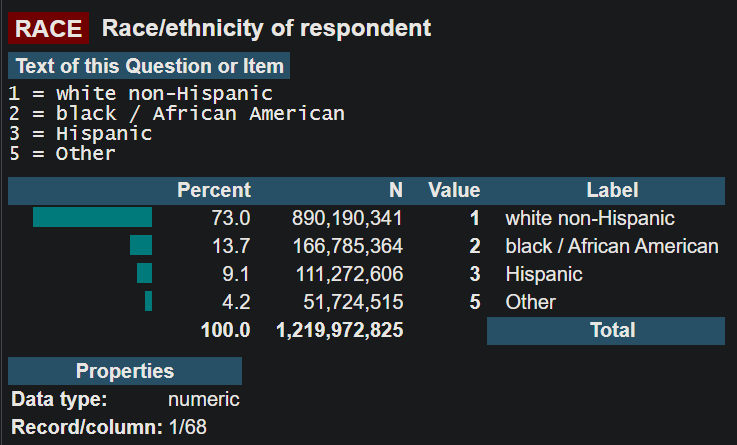

In [19]:
race_dict = {
    1: "White/Non-Hispanic",
    2: "Black/African-American",
    3: "Hispanic",
    5: "Other",
}

In [20]:
race = df_fear["RACE"].replace(race_dict)
race.head(10)

20     Black/African-American
21     Black/African-American
22     Black/African-American
23     Black/African-American
24     Black/African-American
110        White/Non-Hispanic
111        White/Non-Hispanic
112        White/Non-Hispanic
113        White/Non-Hispanic
114        White/Non-Hispanic
Name: RACE, dtype: object

In [21]:
race_value_counts = race.value_counts(normalize=True)
race_value_counts

RACE
White/Non-Hispanic        0.386559
Black/African-American    0.337327
Hispanic                  0.206043
4                         0.050274
Other                     0.019797
Name: proportion, dtype: float64

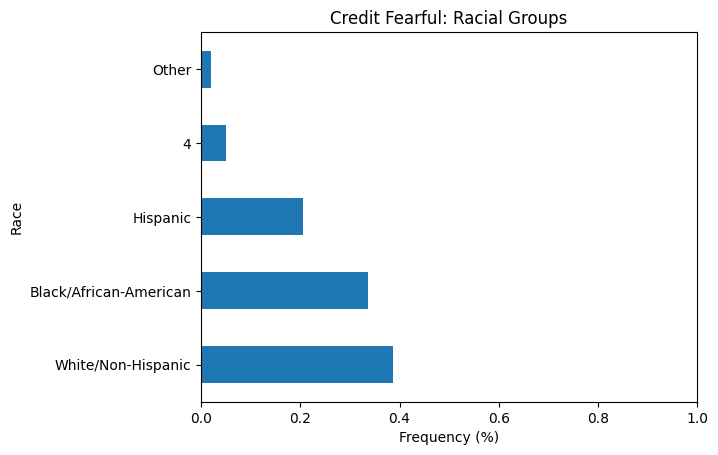

In [22]:
# Create bar chart of race_value_counts
race_value_counts.plot(kind="barh")
plt.xlim((0, 1))
plt.xlabel("Frequency (%)")
plt.ylabel("Race")
plt.title("Credit Fearful: Racial Groups");

**Interpretation:** Credit Fearful by Racial Group

The chart presents the distribution of credit-fearful respondents across racial groups. The results indicate that White/Non-Hispanic individuals account for the largest share of credit-fearful respondents (approximately 39%), followed by Black/African-American respondents (around 34%). Hispanic respondents represent about 21%, while the remaining racial groups constitute only a small proportion of the total sample.

**Key observations:**

- White/Non-Hispanic respondents make up the largest segment of credit-fearful individuals.
- Black/African-American respondents also represent a substantial share, only slightly lower than White respondents.
- Hispanic respondents account for a meaningful but smaller proportion.
- Other racial groups collectively contribute a relatively minor share of credit-fearful respondents.

**Important Note:**

These percentages represent the composition of the credit-fearful population, not the likelihood of being credit fearful within each racial group. To determine which racial group is more likely to experience credit fear, the analysis should compare the number of credit-fearful individuals to the total number of respondents within each racial category (i.e., calculate within-group credit fear rates). Therefore, the chart shows the distribution of credit-fearful respondents across racial groups rather than evidence that any particular racial group is inherently more or less credit fearful.